# PPO with CNN

In [ ]:
!apt-get update -qq
!apt-get install -y -qq swig cmake ffmpeg
!pip uninstall -y gym
!pip install --quiet "gymnasium[box2d]" "stable-baselines3[extra]" shimmy
!pip install pyglet==1.5.27

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Env

In [ ]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces
from gymnasium.wrappers import TimeLimit
import math
import pyglet
from pyglet import shapes

class CarRacing(gym.Env):

    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 50}

    # __init__()
    def __init__(
        self,
        render_mode: str | None = None,
        continuous: bool = True,
        lap_complete_percent: float = 0.95,
        domain_randomize: bool = False,
        reward_shaping: bool = True,
        max_episode_steps: int = 3000,
        max_laps: int = 3,
    ):
        super(CarRacing, self).__init__()
        self._env = gym.make("CarRacing-v3", render_mode=render_mode, continuous=continuous, lap_complete_percent=lap_complete_percent)
        base_env = self._env.unwrapped
        self._env = TimeLimit(base_env, max_episode_steps=max_episode_steps)

        self.render_mode = render_mode
        self.continuous = continuous
        self.lap_complete_percent = lap_complete_percent
        self._reward_shaping = reward_shaping

        # State S_t
        image_space = spaces.Box(0, 255, shape=(96, 96, 3), dtype=np.uint8)

        # state branch: [d_t, v_t, infield, pitroad, ell_t, w_t, f_t, kappa_t, psi_t, v_lat]
        # psi_t (heading error) and v_lat (lateral speed) help the agent keep orientation and stay centred.
        state_low  = np.array([-5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.05, -math.pi, -20.0], dtype=np.float32)
        state_high = np.array([ 5.0, 70.0, 1.0, 1.0, 1.0, 1.0, 1.0,  0.05,  math.pi,  20.0], dtype=np.float32)
        state_space = spaces.Box(low=state_low, high=state_high, dtype=np.float32)

        self.observation_space = spaces.Dict({"image": image_space, "state": state_space})

        # Action A_t
        if self.continuous:
            self.action_space = spaces.Box(
                low=np.array([-1.0, 0.0, 0.0, 0.0], dtype=np.float32),
                high=np.array([1.0, 1.0, 1.0, 1.0], dtype=np.float32),
                shape=(4,),
                dtype=np.float32,
            )
        else:
            # 0:nothing, 1:steer right, 2:steer left, 3:gas, 4:brake, 5:pit
            self.action_space = spaces.Discrete(6)

        # Internal states
        self._wear = 0.0   # 0=new, 1=fully_worn
        self._fuel = 1.0   # 1=full, 0=empty
        self._dt = 1.0 / 50.0  # CarRacing runs at 50 frames per second

        # ===== Fuel (per second) ======
        # At idle: drains slowly, but at full gas: drains more (will need to adjust)
        self.fuel_base_per_s = 0.0015         # idle consumption
        self.fuel_full_per_s = 0.02         # extra at gas=1 (so total ~0.0125/s at speed)

        # Wear (per second)
        self.wear_base_per_s = 0.003         # always-on tiny wear
        self.wear_brake_per_s = 0.0050        # additional at brake=1
        self.wear_steer_per_s = 0.0020        # additional at steer=1

        # ===== Resource thresholds & shaping =====
        # Termination thresholds
        self.fuel_empty_threshold = 0.02    # below ~2% fuel -> out of fuel
        self.wear_max_threshold = 0.98      # above ~98% wear -> tire failure

        # One-time penalties when we actually fail due to resources
        self.fuel_empty_penalty = 30.0
        self.wear_max_penalty = 20.0

        # Small per-step cost for using resources (only applied if reward_shaping=True)
        self.fuel_cost_per_unit = 2.0       # cost * (fuel_before - fuel_after)
        self.wear_cost_per_unit = 1.0       # cost * (wear_after - wear_before)
        # ========================================

        # Speed scaling reference (m/s); above this speed, scaling is 1.0
        self.speed_ref_mps = 40.0 # Will need to adjust based on testing

        self.progress = 0.0 # overall progress in [0,1] if we want to track
        self._last_progress = 0.0

        self._gauge = None # the gauge window

        # ==== Pitstop configuration ====
        self._pit_center_test = False       # toggle to True to center pit stops and test
        self._pit_speed_max = 5.0           # must be slow to service
        self._pit_count = 3               # number of pit sectors per lap
        self._pit_sector_width = 0.0075     # sector width in progress units

        # Painted strip geometry (world-space)
        self._pit_sign = 1.0
        self._pit_inner_offset = 3.2        # start position relative to centerline
        self._pit_width = 3.5               # thickness of the painted strip

        # Detection must match the paint exactly:
        self._pit_polys_count = 0
        self._prev_pitroad     = False
        self._pit_lock_sector  = None        # prevents spamming within the current sector

        self._sync_pit_bounds()
        # ===============================

        # ==== How much wear impacts steering and gas ====
        self.steering_grip_min = 0.3      # min grip at wear=1.0 (30% of steering)
        self.steering_wear_strength = 1.0 # 1.0 = full effect, < 1.0 = weaker effect

        # Multi-lap state
        self.max_laps = max(1, int(max_laps))
        self._current_lap = 1
        self.race_completion_bonus = 50.0  # bonus reward for finishing all laps

    # reset()
    def reset(self, *, seed=None, options=None):
        observation, info = self._env.reset(seed=seed, options=options)

        self.progress = 0.0
        self._last_progress = 0.0

        self._wear = 0.0
        self._fuel = 1.0

        self._prev_pitroad = False

        # reset lap counter
        self._current_lap = 1
        info["lap"] = self._current_lap
        info["max_laps"] = self.max_laps

        # build static painted pit strips onto the track
        try:
            self._sync_pit_bounds()
            self._build_pit_polys()
        except Exception:
            pass

        return self._get_obs(observation), info

    # step()
    def step(self, action):
        # Map our action to base env (3 controls) + pit command
        base_action, pit_command = self._map_action(action)

        # Get actions
        steer, gas, brake = base_action[0], base_action[1], base_action[2]

        # Step in base environment
        observation, reward, terminated, truncated, info = self._env.step(base_action)

        # If the car is off the track surface (and not in the pit),
        # immediately terminate the episode.
        if self._is_infield_from_offset() and not self._is_in_pit():
            terminated = True
            # Optional strong penalty to discourage leaving the track
            reward -= 20.0

        # Get speed from box2d
        velocity = self._get_velocity()

        # Store resources before update for logging/shaping if needed
        fuel_before = self._fuel
        wear_before = self._wear

        # Update resources
        steer, gas, brake = float(base_action[0]), float(base_action[1]), float(base_action[2])

        # Scale effects by speed (0.3 at standstill to 1.0 at speed_ref and above)
        speed_scale = 0.3 + 0.7 * min(1.0, velocity / self.speed_ref_mps)

        # Fuel: from idle to full-throttle rate, then scale by speed.
        fuel_rate_per_s = self.fuel_base_per_s + gas * (self.fuel_full_per_s - self.fuel_base_per_s)
        fuel_rate_per_s *= speed_scale
        self._fuel = max(0.0, self._fuel - self._dt * fuel_rate_per_s)

        # Wear: base + brake + steering contributions, then scale by speed.
        wear_rate_per_s = (
            self.wear_base_per_s
            + brake * self.wear_brake_per_s
            + abs(steer) * self.wear_steer_per_s
        )
        wear_rate_per_s *= speed_scale
        self._wear = min(1.0, self._wear + self._dt * wear_rate_per_s)

        # fuel_used = max(0.0, fuel_before - self._fuel)
        # wear_added = max(0.0, self._wear - wear_before)

        # # Optional per-step shaping: small penalty for burning fuel / tires
        # if self._reward_shaping:
        #     reward -= self.fuel_cost_per_unit * fuel_used
        #     reward -= self.wear_cost_per_unit * wear_added

        # ==== Resource-based termination conditions ====
        out_of_fuel = (self._fuel <= self.fuel_empty_threshold)
        tires_gone = (self._wear >= self.wear_max_threshold)

        if out_of_fuel:
            terminated = True
            if self._reward_shaping:
                reward -= self.fuel_empty_penalty

        if tires_gone:
            terminated = True
            if self._reward_shaping:
                reward -= self.wear_max_penalty

        # ==== Multi-lap logic ====
        # per-lap progress on the current track
        ell_t = self._env.unwrapped.tile_visited_count / len(self._env.unwrapped.track)

        env_done = bool(terminated or truncated)
        lap_finished = env_done and (ell_t >= self.lap_complete_percent - 1e-6)

        info["lap"] = self._current_lap
        info["max_laps"] = self.max_laps
        info["lap_finished"] = False
        info["finished_lap"] = None
        info["reset_for_new_lap"] = False
        info["race_finished"] = False

        race_finished = False

        if lap_finished:
            info["lap_finished"] = True
            info["finished_lap"] = self._current_lap
            race_finished = (self._current_lap >= self.max_laps)
            print(f"--- Lap {self._current_lap} Finished! ---")

        if lap_finished and self._current_lap < self.max_laps:
            # Finished a lap but not the whole race: start a new lap
            finished_lap = self._current_lap
            self._current_lap += 1
            info["lap_finished"] = True
            info["finished_lap"] = finished_lap
            info["lap"] = self._current_lap

            # Reset underlying env to start the next lap
            observation, info_reset = self._env.reset()

            # Keep fuel/wear across laps (endurance), but reset some internal race state
            self.progress = 0.0
            self._last_progress = 0.0
            self._prev_pitroad = False
            self._pit_lock_sector = None

            try:
                self._sync_pit_bounds()
                self._build_pit_polys()
            except Exception:
                pass

            # Don't end the episode from the agent's POV
            terminated = False
            truncated = False

            # Recompute progress on the fresh lap
            ell_t = self._env.unwrapped.tile_visited_count / len(self._env.unwrapped.track)
            info["reset_for_new_lap"] = True
        elif race_finished:
            info["race_finished"] = True
            # One-time bonus for completing every lap in the race
            reward += self.race_completion_bonus
            print(f"--- Race Finished! All {self.max_laps} Laps Completed! ---")
        else:
            # Race progress across all laps [0,1]
            if self.max_laps > 0:
                self.progress = ((self._current_lap - 1) + ell_t) / float(self.max_laps)
        d_t = self._compute_offset()

        tile_idx = self._nearest_tile_index()   # tile index drives sector logic
        in_sector, sector_idx = self._sector_state_by_index(tile_idx)
        in_strip = (self._pit_d_min <= d_t <= self._pit_d_max)
        pitroad = bool(in_sector and in_strip)

        # edge logs
        pit_enter = pitroad and not self._prev_pitroad
        pit_exit  = (not pitroad) and self._prev_pitroad
        self._prev_pitroad = pitroad

        # clear lock when we're not in any sector (so next sector can service)
        if not in_sector:
            self._pit_lock_sector = None

        fuel_before_service = self._fuel
        wear_before_service = self._wear
        pit_executed = False
        if pit_enter and pit_command and (velocity < self._pit_speed_max):
            # only service if we haven't serviced this sector yet
            if self._pit_lock_sector is None or self._pit_lock_sector != sector_idx:
                self._pit_lock_sector = sector_idx
                self._fuel = 1.0
                self._wear = 0.0
                pit_executed = True
                print(f"[PIT] SERVICE at sector={sector_idx} ell={ell_t:.3f} d_t={d_t:+.2f} fuel_before={fuel_before_service:.3f} wear_before={wear_before_service:.3f}")

        # Reward sensible pit-stops, mildly discourage pointless ones
        if self._reward_shaping and pit_executed:
            if (fuel_before_service < 0.5) or (wear_before_service > 0.5):
                reward += 5.0   # reward only when pit was needed
            else:
                reward -= 2.0   # pitting too early: small cost

        # logs to check edges
        if pit_enter:
            print(f"[PIT] ENTER sector={sector_idx} ell={ell_t:.3f} d_t={d_t:+.2f}")
        if pit_exit:
            print(f"[PIT] EXIT  ell={ell_t:.3f} d_t={d_t:+.2f}")
        # ==================================

        info["pitroad"] = pitroad
        info["pit_enter"] = pit_enter
        info["pit_exit"] = pit_exit
        info["pit_executed"] = pit_executed
        info["ell"] = float(ell_t)
        info["d_t"] = float(d_t)
        info["out_of_fuel"] = bool(out_of_fuel)
        info["tires_gone"] = bool(tires_gone)
        info["fuel"] = float(self._fuel)
        info["wear"] = float(self._wear)

        # Update observation
        return self._get_obs(observation), reward, terminated, truncated, info

    # render()
    def render(self):
        if self.render_mode == "rgb_array":
            return self._env.render()
        out = self._env.render()

        # Update or create the separate gauge window
        try:
            self._ensure_gauge_window()
            self._gauge.update(fuel=self._fuel, tire_health=1.0 - self._wear)
        except Exception:
            pass

        return out

    def close(self):
        try:
            if self._gauge is not None:
                self._gauge.close()
                self._gauge = None
        except Exception:
            pass
        self._env.close()

    # Helper Functions
    def _map_action(self, action):
        # Base CarRacing expects only 3 controls, so we keep 'pit' separate
        if self.continuous:
            a = np.asarray(action, dtype=np.float32)
            if a.shape[0] < 4:
                a = np.concatenate([a, np.array([0.0], dtype=np.float32)], axis=0)
            steer = float(np.clip(a[0], -1.0, 1.0))
            gas   = float(np.clip(a[1],  0.0, 1.0))
            brake = float(np.clip(a[2],  0.0, 1.0))
            pit   = bool(a[3] >= 0.5)

            # ==== wear-dependent steering and throttle ====
            # g(wear) in [steering_grip_min, 1.0]
            grip = 1.0 - self.steering_wear_strength * self._wear
            grip = float(np.clip(grip, self.steering_grip_min, 1.0))
            steer *= grip

            # Throttle (acceleration) also affected by grip
            gas *= grip

            return np.array([steer, gas, brake], dtype=np.float32), pit
        else:
            a = int(action)
            pit = (a == 5)
            if a == 0:   base = np.array([0.0, 0.0, 0.0], dtype=np.float32)
            elif a == 1: base = np.array([+1.0, 0.0, 0.0], dtype=np.float32)
            elif a == 2: base = np.array([-1.0, 0.0, 0.0], dtype=np.float32)
            elif a == 3: base = np.array([0.0, 1.0, 0.0], dtype=np.float32)
            elif a == 4: base = np.array([0.0, 0.0, 1.0], dtype=np.float32)
            elif a == 5: base = np.array([0.0, 0.0, 0.0], dtype=np.float32)
            else: raise ValueError(f"Invalid discrete action {a}")

            # Same grip logic for discrete mode
            grip = 1.0 - self.steering_wear_strength * self._wear
            grip = float(np.clip(grip, self.steering_grip_min, 1.0))
            steer = float(base[0]) * grip
            base = np.array([steer, base[1], base[2]], dtype=np.float32)

            return base, pit

    def _get_obs(self, base_obs):
        d_t = self._compute_offset()
        v_t = self._get_velocity()
        ell_t = self._env.unwrapped.tile_visited_count / len(self._env.unwrapped.track)

        tile_idx = self._nearest_tile_index()
        track_heading = self._track_heading(tile_idx)
        heading_error = self._angle_diff(self._env.unwrapped.car.hull.angle, track_heading)
        _, v_lat = self._velocity_components(track_heading)

        infield = self._is_infield_from_offset()
        pitroad = self._is_in_pit()

        kappa_t = self._compute_lookahead_curvature()

        state_vec = np.array([
            float(np.clip(d_t, -5.0, 5.0)), # d_t: lateral distance from track center
            float(np.clip(v_t, 0.0, 70.0)), # v_t: current velocity
            1.0 if infield else 0.0, # infield: whether the car is in the infield
            1.0 if pitroad else 0.0, # pitroad: whether the car is on the pit road
            float(np.clip(ell_t, 0.0, 1.0)), # ell_t: progress along the track
            float(np.clip(self._wear, 0.0, 1.0)), # w_t: tire wear
            float(np.clip(self._fuel, 0.0, 1.0)), # f_t: fuel level
            float(np.clip(kappa_t, -0.05, 0.05)), # kappa_t: track curvature
            float(np.clip(heading_error, -math.pi, math.pi)), # psi_t: heading error vs track
            float(np.clip(v_lat, -20.0, 20.0)), # v_lat: lateral speed relative to track
        ], dtype=np.float32)

        return {"image": base_obs, "state": state_vec}

    def _compute_offset(self):
        env = self._env.unwrapped

        # Car position in Box2D world coordinates
        car_position = env.car.hull.position
        car_x, car_y = float(car_position[0]), float(car_position[1])

        track = env.track
        if not track or len(track) == 0:
            return 0.0

        # Find the track tile whose center (x, y) is closest to the car
        min_distance_squared = float("inf")
        nearest_tile_index = 0
        for i, (tile_alpha, tile_beta, tile_center_x, tile_center_y) in enumerate(track):
            delta_x = car_x - tile_center_x
            delta_y = car_y - tile_center_y
            distance_squared = delta_x * delta_x + delta_y * delta_y
            if distance_squared < min_distance_squared:
                min_distance_squared = distance_squared
                nearest_tile_index = i

        # Get the center and orientation (beta) of that nearest tile
        _, nearest_tile_beta, nearest_tile_center_x, nearest_tile_center_y = track[nearest_tile_index]

        # Compute vector from centerline point to car
        vector_to_car_x, vector_to_car_y = car_x - nearest_tile_center_x, car_y - nearest_tile_center_y

        # Road normal is (cos(beta), sin(beta)) as used in gym's create_track()
        # It is a vector that points sideways, perpendicular to the direction you are driving
        road_normal_x, road_normal_y = math.cos(nearest_tile_beta), math.sin(nearest_tile_beta)

        # Signed lateral offset = projection of w onto the normal,
        signed_distance = (vector_to_car_x * road_normal_x + vector_to_car_y * road_normal_y)

        return float(signed_distance)

    def _compute_lookahead_curvature(self):
        """
        Estimate signed track curvature ahead of the car by looking at how the
        road orientation (beta) changes over the next few tiles.

        Positive kappa_t  -> turning one way
        Negative kappa_t  -> turning the other way
        """
        env = self._env.unwrapped
        track = getattr(env, "track", None)

        # Need at least 2 tiles to define a turn
        if not track or len(track) < 2:
            return 0.0

        n = len(track)
        lookahead_tiles = 12 # how many segments ahead to average over

        # Start from the tile closest to the car
        idx = self._nearest_tile_index()

        total_delta = 0.0
        samples = 0

        for k in range(lookahead_tiles):
            i0 = (idx + k) % n
            i1 = (idx + k + 1) % n

            _, beta0, _, _ = track[i0]
            _, beta1, _, _ = track[i1]

            d_beta = self._angle_diff(beta1, beta0) # in [-pi, pi]
            total_delta += d_beta
            samples += 1

        if samples == 0:
            return 0.0

        # Average turn per segment (radians)
        avg_delta = total_delta / float(samples)

        # Normalize to [-1, 1] by dividing by pi, then scale down to about [-0.05, 0.05]
        kappa = (avg_delta / math.pi) * 0.05

        return float(kappa)


    def _is_infield_from_offset(self):
        # Placeholder implementation
        # return False
        # use lateral offset d_t from the track centerline. If |d_t| > 4.0 meters, treat as infield/off-track.
        d_t = self._compute_offset()
        return abs(d_t) > 4.0

    def _nearest_tile_index(self):
        """
        Index of the track tile whose center is closest
        to the car (aligns pit logic with painted tiles).
        """
        env = self._env.unwrapped
        track = env.track
        if not track:
            return 0
        car_x, car_y = float(env.car.hull.position[0]), float(env.car.hull.position[1])
        best_i, best_d2 = 0, float("inf")
        for i, (_, _, cx, cy) in enumerate(track):
            dx, dy = car_x - cx, car_y - cy
            d2 = dx*dx + dy*dy
            if d2 < best_d2:
                best_d2, best_i = d2, i
        return best_i

    @staticmethod
    def _angle_diff(a: float, b: float) -> float:
        """
        Smallest signed difference between two angles a and b, in radians,
        wrapped into [-pi, pi].
        """
        d = a - b
        # Wrap using atan2(sin, cos) for numerical stability
        return math.atan2(math.sin(d), math.cos(d))

    def _track_heading(self, tile_idx: int | None = None) -> float:
        """
        Heading of the track centreline at the current tile, derived from the
        direction between consecutive tile centres.
        """
        env = self._env.unwrapped
        track = getattr(env, "track", None)
        if not track or len(track) < 2:
            return 0.0
        if tile_idx is None:
            tile_idx = self._nearest_tile_index()
        n = len(track)
        i_next = (tile_idx + 1) % n
        _, _, cx0, cy0 = track[tile_idx]
        _, _, cx1, cy1 = track[i_next]
        return math.atan2(cy1 - cy0, cx1 - cx0)

    def _velocity_components(self, track_heading: float):
        """
        Resolve car velocity into components aligned with the track heading.
        """
        vx, vy = float(self._env.unwrapped.car.hull.linearVelocity[0]), float(self._env.unwrapped.car.hull.linearVelocity[1])
        v_long = vx * math.cos(track_heading) + vy * math.sin(track_heading)
        v_lat = -vx * math.sin(track_heading) + vy * math.cos(track_heading)
        return v_long, v_lat

    def _sector_state_by_index(self, tile_idx: int):
        """
        Given a tile index, return (in_sector, sector_idx)
        consistent with paint logic where prog = i / n.
        """
        env = self._env.unwrapped
        n = max(1, len(env.track))
        count = max(1, int(self._pit_count))
        step = 1.0 / float(count)                 # sector length in progress units
        width = float(self._pit_sector_width)     # painted width in progress units

        prog = tile_idx / float(n)
        sector_idx = (tile_idx * count) // n
        start = sector_idx * step

        # tiny epsilon eliminates fencepost disagreement
        eps = 1e-9
        in_sector = (start - eps <= prog <= start + width + eps)
        return in_sector, int(sector_idx)

    def _sync_pit_bounds(self):
        """
        Set lateral pit detection [d_min, d_max] to exactly
        match how the pit strip is drawn (centered or sided).
        """
        if self._pit_center_test:
            half = float(abs(self._pit_width)) / 2.0
            self._pit_d_min, self._pit_d_max = -half, +half
        else:
            inner = float(abs(self._pit_inner_offset))
            strip_w = float(abs(self._pit_width))
            d_hi = self._pit_sign * inner
            d_lo = self._pit_sign * (inner + strip_w)
            self._pit_d_min, self._pit_d_max = (min(d_lo, d_hi), max(d_lo, d_hi))

    def _is_in_pit(self, d_t=None, ell_t=None):
        """
        Return True iff current lateral offset is within
        pit bounds and the current tile lies in a pit sector.
        """
        try:
            if d_t is None:
                d_t = self._compute_offset()
            tile_idx = self._nearest_tile_index()
            in_sector, _ = self._sector_state_by_index(tile_idx)
            in_strip = (self._pit_d_min <= d_t <= self._pit_d_max)
            return bool(in_sector and in_strip)
        except Exception:
            return False

    def _get_velocity(self):
        v_t = self._env.unwrapped.car.hull.linearVelocity
        return np.linalg.norm(v_t)

    def _ensure_gauge_window(self):
        if self._gauge is not None:
            return
        try:
            self._gauge = _GaugeWindow(title="Fuel & Tire Gauges", width=280, height=110)
        except Exception:
            self._gauge = None

    def _build_pit_polys(self):
        """
        Build painted pit quads on the track.
        """
        env = self._env.unwrapped
        track = getattr(env, "track", None)
        if not track or len(track) < 2:
            return

        try:
            if self._pit_polys_count > 0:
                env.road_poly = env.road_poly[:-self._pit_polys_count]
                self._pit_polys_count = 0
        except Exception:
            self._pit_polys_count = 0

        n = len(track)
        count = max(1, int(self._pit_count))
        step = 1.0 / float(count)
        width_prog = float(self._pit_sector_width)

        PIT_COLOR = (255, 140, 0) # orange

        def lateral_offset(cx, cy, beta, offset_m):
            nx, ny = math.cos(beta), math.sin(beta)
            return (cx + offset_m * nx, cy + offset_m * ny)

        added = 0
        for i in range(n - 1):
            prog = i / float(n)
            k = int((prog % 1.0) / step)
            start = k * step
            if not (start <= prog <= start + width_prog):
                continue

            _, beta_i, cx_i, cy_i = track[i]
            _, beta_j, cx_j, cy_j = track[i + 1]

            if self._pit_center_test:
                half = float(abs(self._pit_width)) / 2.0
                # left/right edges around the centerline
                ix_i, iy_i = lateral_offset(cx_i, cy_i, beta_i, -half)
                ox_i, oy_i = lateral_offset(cx_i, cy_i, beta_i, +half)
                ix_j, iy_j = lateral_offset(cx_j, cy_j, beta_j, -half)
                ox_j, oy_j = lateral_offset(cx_j, cy_j, beta_j, +half)
            else:
                inner = float(abs(self._pit_inner_offset))
                strip_w = float(abs(self._pit_width))
                # right side using sign
                ix_i, iy_i = lateral_offset(cx_i, cy_i, beta_i, self._pit_sign * inner)
                ox_i, oy_i = lateral_offset(cx_i, cy_i, beta_i, self._pit_sign * (inner + strip_w))
                ix_j, iy_j = lateral_offset(cx_j, cy_j, beta_j, self._pit_sign * inner)
                ox_j, oy_j = lateral_offset(cx_j, cy_j, beta_j, self._pit_sign * (inner + strip_w))

            quad = [(ix_i, iy_i), (ox_i, oy_i), (ox_j, oy_j), (ix_j, iy_j)]
            try:
                env.road_poly.append((quad, PIT_COLOR))
                added += 1
            except Exception:
                break

        self._pit_polys_count = added

class _GaugeWindow:
    def __init__(self, title="Fuel & Tire Gauges", width=280, height=110):
        self._pyglet = pyglet
        self.window = pyglet.window.Window(width=width, height=height, caption=title, resizable=False, vsync=False)
        self.batch = pyglet.graphics.Batch()
        self.shapes = {}
        self.labels = {}

        # Layout
        self.margin = 30
        self.bar_w = width - self.margin*2
        self.bar_h = 16
        self.gap = 30

        # Colors
        self.col_bg   = (25, 25, 25)
        self.col_ok   = (80, 200, 120)
        self.col_warn = (240, 200, 80)
        self.col_crit = (230, 80, 80)
        self.col_text = (240, 240, 240, 255)

        # Draws Fuel bar at the top and Tire Wear bar below
        self._make_row("FUEL", y_top=height - self.margin)
        self._make_row("TIRE WEAR", y_top=height - self.margin - (self.bar_h + self.gap))

        # initial draw
        self.update(1.0, 1.0)

    def _make_row(self, name, y_top):
        x0 = self.margin
        self.shapes[(name, "bg")]   = shapes.Rectangle(x0, y_top - self.bar_h, self.bar_w, self.bar_h, color=self.col_bg, batch=self.batch)
        self.shapes[(name, "fill")] = shapes.Rectangle(x0, y_top - self.bar_h, 1, self.bar_h, color=self.col_ok, batch=self.batch)
        self.labels[(name, "left")] = self._pyglet.text.Label(
            name, font_size=10, color=self.col_text, x=x0, y=y_top + 2,
            anchor_x="left", anchor_y="baseline", batch=self.batch
        )
        self.labels[(name, "right")] = self._pyglet.text.Label(
            "100%", font_size=10, color=self.col_text, x=x0 + self.bar_w, y=y_top - self.bar_h + 2,
            anchor_x="right", anchor_y="baseline", batch=self.batch
        )

    def _colour_format(self, v):
        if v > 0.5: return self.col_ok
        if v > 0.2: return self.col_warn
        return self.col_crit

    def update(self, fuel, tire_health):
        pyglet = self._pyglet

        # Keep window responsive
        pyglet.clock.tick()
        self.window.switch_to()
        self.window.dispatch_events()

        fuel = float(np.clip(fuel, 0.0, 1.0))
        tire = float(np.clip(tire_health, 0.0, 1.0))

        # Update fills + labels
        f_fill = self.shapes[("FUEL", "fill")]
        f_fill.width = int(self.bar_w * fuel)
        f_fill.color = self._colour_format(fuel)

        t_fill = self.shapes[("TIRE WEAR", "fill")]
        t_fill.width = int(self.bar_w * tire)
        t_fill.color = self._colour_format(tire)

        self.labels[("FUEL", "right")].text = f"{int(fuel*100)}%"
        self.labels[("TIRE WEAR", "right")].text = f"{int(tire*100)}%"

        # Draw this frame
        self.window.clear()
        self.batch.draw()
        self.window.flip()

    def close(self):
        try:
            self.window.close()
        except Exception:
            pass


# Agent


In [ ]:
import torch
import torch.nn as nn
from gymnasium import spaces
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor


class CarRacingFeatureExtractor(BaseFeaturesExtractor):
    """
    Custom feature extractor for Dict observation:
      - "image": (C, H, W) after SB3 preprocessing (e.g. (3, 96, 96))
      - "state": (N_state,) float
    CNN on image + MLP on state, then concat + projection.
    """

    def __init__(self, observation_space: spaces.Dict, features_dim: int = 256):
        # We will set self._features_dim manually after building the nets
        super().__init__(observation_space, features_dim=1)

        # --- Get subspaces ---
        image_space = observation_space.spaces["image"]
        state_space = observation_space.spaces["state"]

        assert len(image_space.shape) == 3, "Image must be 3D (C, H, W)"
        assert len(state_space.shape) == 1, "State must be 1D vector"

        # SB3 has already converted to CHW, so:
        c, h, w = image_space.shape
        n_input_channels = c

        # --- CNN for the image branch ---
        self.cnn = nn.Sequential(
            nn.Conv2d(n_input_channels, 16, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
        )

        # Dummy forward to get CNN output dim
        with torch.no_grad():
            dummy = torch.zeros(1, n_input_channels, h, w)
            cnn_out_dim = self.cnn(dummy).shape[1]

        # --- MLP for the state branch ---
        state_dim = state_space.shape[0]
        self.state_net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
        )
        state_out_dim = 64

        # Combined dim before projection
        combined_dim = cnn_out_dim + state_out_dim

        # Optional projection to features_dim for the policy/value nets
        self.proj = nn.Sequential(
            nn.Linear(combined_dim, features_dim),
            nn.ReLU(),
        )
        self._features_dim = features_dim

    def forward(self, observations):
        # observations["image"] is already (B, C, H, W) thanks to SB3 preprocessing
        img = observations["image"].float() / 255.0
        state = observations["state"].float()

        img_feat = self.cnn(img)
        state_feat = self.state_net(state)

        concat = torch.cat([img_feat, state_feat], dim=1)
        return self.proj(concat)


In [ ]:
import os
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import CheckpointCallback
from datetime import datetime

# Base log directory
base_log_dir = "/content/drive/MyDrive/COMP4010-Project/ppo_carracing_logs"

# Create a unique log directory with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
log_dir = os.path.join(base_log_dir, f"run_{timestamp}")
os.makedirs(log_dir, exist_ok=True)

def make_env():
    # configure your custom env here
    return CarRacing(
        render_mode=None,
        continuous=True,
        lap_complete_percent=0.95,
        domain_randomize=False,
        reward_shaping=True,
        max_episode_steps=3000,
        max_laps=3,
    )

# 4 parallel envs
n_envs = 4

vec_env = make_vec_env(
    make_env,
    n_envs=n_envs,
    vec_env_cls=DummyVecEnv,
)

# Monitor to log episode reward/length to CSV
monitor_path = os.path.join(log_dir, "monitor.csv")
vec_env = VecMonitor(vec_env, filename=monitor_path)

checkpoint_callback = CheckpointCallback(
    save_freq=200_000 // n_envs,
    save_path=log_dir,
    name_prefix="ppo_carracing",
)

policy_kwargs = dict(
    features_extractor_class=CarRacingFeatureExtractor,
    features_extractor_kwargs=dict(features_dim=256),
    net_arch=[256, 256],
)

model = PPO(
    policy="MultiInputPolicy",
    env=vec_env,
    policy_kwargs=policy_kwargs,
    n_steps=4096,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.01,
    learning_rate=1e-4,
    clip_range=0.2,
    vf_coef=0.5,
    max_grad_norm=0.5,
    tensorboard_log=log_dir,
    verbose=1,
)

total_timesteps = 1000000
model.learn(total_timesteps=total_timesteps, callback=checkpoint_callback)

model.save(os.path.join(log_dir, "ppo_carracing_final"))
vec_env.close()

Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /content/drive/MyDrive/COMP4010-Project/ppo_carracing_logs/run_20251207_170100/PPO_1


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/vec_monitor.py:44: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.41e+03 |
|    ep_rew_mean     | -103     |
| time/              |          |
|    fps             | 97       |
|    iterations      | 1        |
|    time_elapsed    | 168      |
|    total_timesteps | 16384    |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.51e+03    |
|    ep_rew_mean          | -106        |
| time/                   |             |
|    fps                  | 95          |
|    iterations           | 2           |
|    time_elapsed         | 343         |
|    total_timesteps      | 32768       |
| train/                  |             |
|    approx_kl            | 0.004595412 |
|    clip_fraction        | 0.0225      |
|    clip_range           | 0.2         |
|    entropy_loss         | -5.68       |
|    explained_variance   | 0.00197     |
|    learning_rate        | 0.

# Eval

In [ ]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from stable_baselines3.common.evaluation import evaluate_policy

video_folder = "/content/drive/MyDrive/COMP4010-Project/videos"
os.makedirs(video_folder, exist_ok=True)

# Reload model (optional if still in memory)
model_path = os.path.join(log_dir, "ppo_carracing_final.zip")
model = PPO.load(model_path)

# Create eval env with rgb_array rendering (needed for RecordVideo)
eval_env = CarRacing(
    render_mode="rgb_array",
    continuous=True,
    lap_complete_percent=0.95,
    domain_randomize=False,
    reward_shaping=True,
    max_episode_steps=3000,
    max_laps=3,
)

# Wrap with RecordVideo; record the first episode
recorded_env = RecordVideo(
    eval_env,
    video_folder=video_folder,
    episode_trigger=lambda ep_id: True,  # record first episode
    name_prefix="ppo_carracing_eval",
)

obs, info = recorded_env.reset()
done = False
truncated = False

ep_reward = 0.0

while not (done or truncated):
    # SB3 expects batched obs; RecordVideo uses Gymnasium API (no VecEnv)
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = recorded_env.step(action)
    ep_reward += reward

print(f"Episode reward: {ep_reward}")
recorded_env.close()
eval_env.close()


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/COMP4010-Project/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---
Episode reward: 2515.3000000002007


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


In [ ]:
import glob
from IPython.display import HTML
import base64

# Get the latest video
list_of_videos = glob.glob(os.path.join(video_folder, "*.mp4"))
latest_video = max(list_of_videos, key=os.path.getctime)
print("Showing:", latest_video)

# Display video
video = open(latest_video, "rb").read()
video_b64 = base64.b64encode(video).decode("utf-8")
HTML(f"""
<video width="640" height="480" controls>
  <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
</video>
""")


Showing: /content/drive/MyDrive/COMP4010-Project/videos/ppo_carracing_eval-episode-0.mp4


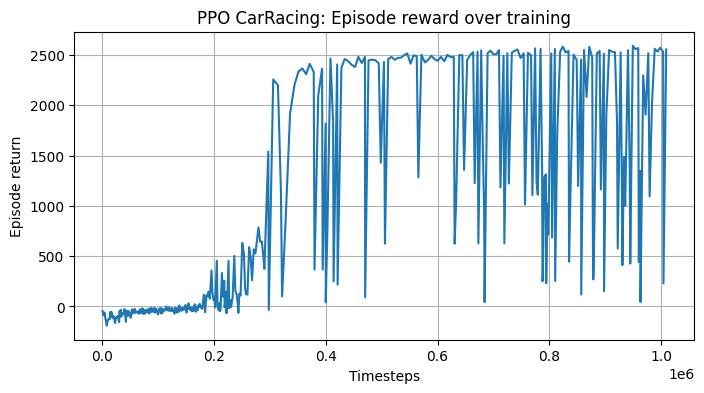

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

monitor_path = "/content/drive/MyDrive/COMP4010-Project/ppo_carracing_logs/run_20251207_170100/monitor.csv"

# Stable-Baselines3 monitor file has some header comments starting with '#'
data = pd.read_csv(monitor_path, skiprows=1)

# timesteps is cumulative; if it's missing, you can approximate
# but SB3's VecMonitor writes "l", "t", "r" by default (length, time, reward).
# We'll add a crude running total of episode lengths as x-axis:
data["timesteps"] = data["l"].cumsum()

plt.figure(figsize=(8, 4))
plt.plot(data["timesteps"], data["r"])
plt.xlabel("Timesteps")
plt.ylabel("Episode return")
plt.title("PPO CarRacing: Episode reward over training")
plt.grid(True)
plt.show()


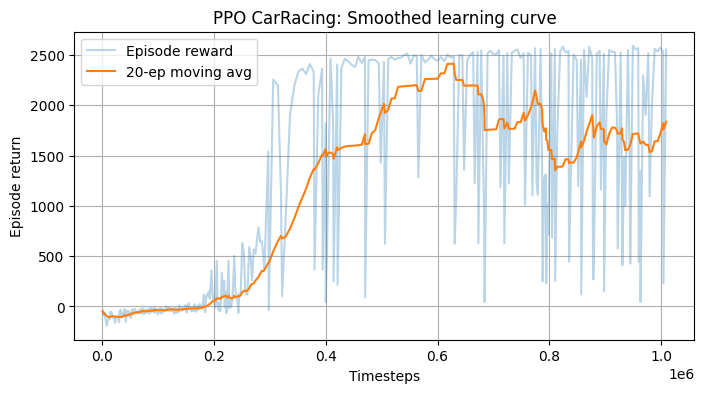

In [ ]:
window = 20  # episodes in smoothing window
data["r_smooth"] = data["r"].rolling(window, min_periods=1).mean()

plt.figure(figsize=(8, 4))
plt.plot(data["timesteps"], data["r"], alpha=0.3, label="Episode reward")
plt.plot(data["timesteps"], data["r_smooth"], label=f"{window}-ep moving avg")
plt.xlabel("Timesteps")
plt.ylabel("Episode return")
plt.title("PPO CarRacing: Smoothed learning curve")
plt.legend()
plt.grid(True)
plt.show()


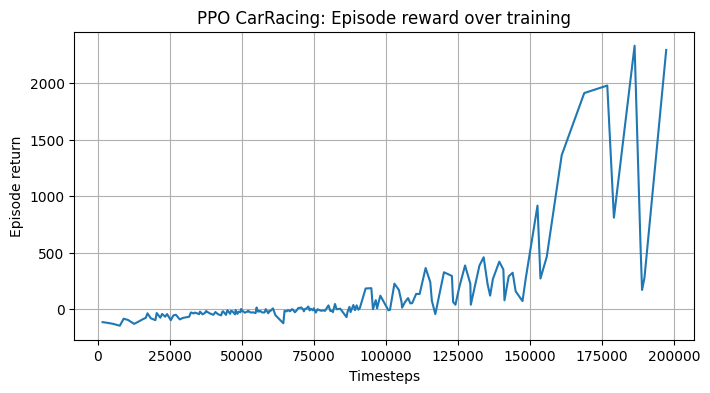

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

monitor_path = os.path.join(log_dir, "monitor.csv")

# Stable-Baselines3 monitor file has some header comments starting with '#'
data = pd.read_csv(monitor_path, skiprows=1)

# timesteps is cumulative; if it's missing, you can approximate
# but SB3's VecMonitor writes "l", "t", "r" by default (length, time, reward).
# We'll add a crude running total of episode lengths as x-axis:
data["timesteps"] = data["l"].cumsum()

plt.figure(figsize=(8, 4))
plt.plot(data["timesteps"], data["r"])
plt.xlabel("Timesteps")
plt.ylabel("Episode return")
plt.title("PPO CarRacing: Episode reward over training")
plt.grid(True)
plt.show()


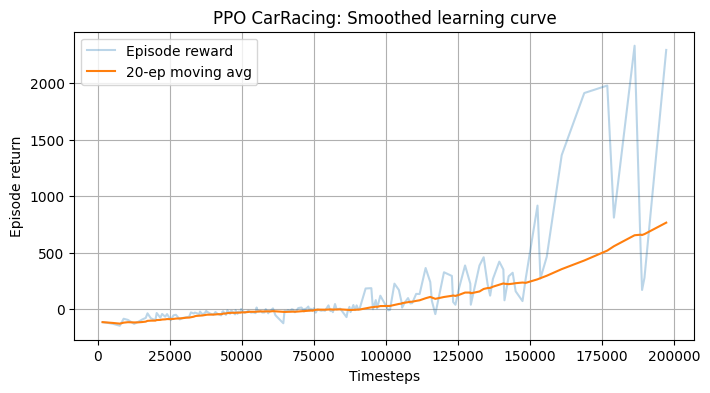

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
window = 20  # episodes in smoothing window
data["r_smooth"] = data["r"].rolling(window, min_periods=1).mean()

plt.figure(figsize=(8, 4))
plt.plot(data["timesteps"], data["r"], alpha=0.3, label="Episode reward")
plt.plot(data["timesteps"], data["r_smooth"], label=f"{window}-ep moving avg")
plt.xlabel("Timesteps")
plt.ylabel("Episode return")
plt.title("PPO CarRacing: Smoothed learning curve")
plt.legend()
plt.grid(True)
plt.show()


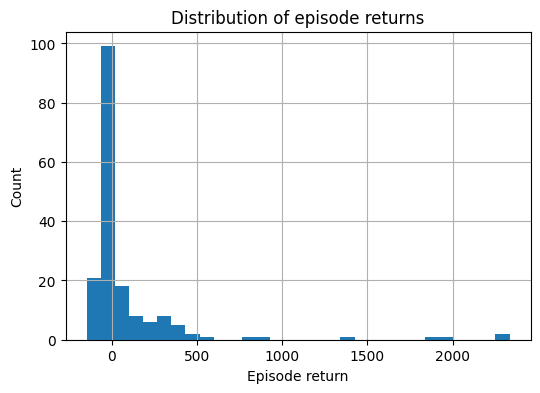

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(data["r"], bins=30)
plt.xlabel("Episode return")
plt.ylabel("Count")
plt.title("Distribution of episode returns")
plt.grid(True)
plt.show()


In [ ]:
%load_ext tensorboard
%tensorboard --logdir $log_dir


# Hyperparameter Experiments

In [ ]:
import os
import time
from dataclasses import dataclass, asdict
from typing import List

import gymnasium as gym
import numpy as np
import pandas as pd

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy

# Make sure these are already defined in the notebook:
# from car_racing import CarRacing as CustomCarRacing
# class CarRacingFeatureExtractor(...): ...


# ---------- 1. Experiment config ----------

@dataclass
class PPOConfig:
    name: str
    learning_rate: float
    n_steps: int
    seed: int = 0
    total_timesteps: int = 300_000  # adjust if you want shorter/longer runs
    n_envs: int = 4


# Example: sweep learning rate first (all with same n_steps)
# configs: List[PPOConfig] = [
#     PPOConfig(name="lr_1e-4", learning_rate=1e-4, n_steps=2048),
#     PPOConfig(name="lr_3e-4", learning_rate=3e-4, n_steps=2048),
#     PPOConfig(name="lr_1e-3", learning_rate=1e-3, n_steps=2048),
# ]

configs = [
    PPOConfig(name="nsteps_1024", learning_rate=3e-4, n_steps=1024),
    PPOConfig(name="nsteps_2048", learning_rate=3e-4, n_steps=2048),
    PPOConfig(name="nsteps_4096", learning_rate=3e-4, n_steps=4096),
]


# ---------- 2. Env factory functions ----------

def make_training_env():
    # Same settings you used for PPO+CNN training
    return CarRacing(
        render_mode=None,
        continuous=True,
        lap_complete_percent=0.95,
        domain_randomize=False,
        reward_shaping=True,
        max_episode_steps=3000,
        max_laps=3,
    )


def make_eval_env():
    # Evaluation env; no need for rgb_array unless you also want videos
    return CarRacing(
        render_mode=None,
        continuous=True,
        lap_complete_percent=0.95,
        domain_randomize=False,
        reward_shaping=True,
        max_episode_steps=3000,
        max_laps=3,
    )


# ---------- 3. Run experiments ----------

results = []

base_log_dir = "/content/drive/MyDrive/COMP4010-Project/ppo_cnn_hparam_experiments"
os.makedirs(base_log_dir, exist_ok=True)

for cfg in configs:
    print(f"\n=== Running config: {cfg.name} (lr={cfg.learning_rate}, n_steps={cfg.n_steps}) ===")

    # --- Logging / monitor paths ---
    log_dir = os.path.join(base_log_dir, cfg.name)
    os.makedirs(log_dir, exist_ok=True)
    monitor_path = os.path.join(log_dir, "monitor.csv")

    # --- Vectorized env with monitor ---
    def env_fn():
        env = make_training_env()
        return env

    vec_env = make_vec_env(
        env_fn,
        n_envs=cfg.n_envs,
        vec_env_cls=DummyVecEnv,
        seed=cfg.seed,
    )
    vec_env = VecMonitor(vec_env, filename=monitor_path)

    # --- Policy kwargs with custom feature extractor ---
    policy_kwargs = dict(
        features_extractor_class=CarRacingFeatureExtractor,
        features_extractor_kwargs=dict(features_dim=256),
        net_arch=[256, 256],
    )

    # --- Create PPO model ---
    model = PPO(
        policy="MultiInputPolicy",
        env=vec_env,
        policy_kwargs=policy_kwargs,
        n_steps=cfg.n_steps,
        batch_size=256,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        ent_coef=0.01,
        learning_rate=cfg.learning_rate,
        clip_range=0.2,
        vf_coef=0.5,
        max_grad_norm=0.5,
        tensorboard_log=log_dir,
        verbose=1,
        seed=cfg.seed,
    )

    # --- Train and time it ---
    start_time = time.time()
    model.learn(total_timesteps=cfg.total_timesteps)
    train_time = time.time() - start_time
    print(f"[{cfg.name}] Training finished in {train_time/60:.2f} minutes")

    # --- Save model ---
    model_path = os.path.join(log_dir, f"{cfg.name}_final")
    model.save(model_path)

    # --- Load monitor data for final episode return estimate ---
    try:
        monitor_df = pd.read_csv(monitor_path, skiprows=1)
        # last 20 episodes mean return
        mean_return_last_20 = monitor_df["r"].tail(20).mean()
    except Exception as e:
        print(f"Could not read monitor file for {cfg.name}: {e}")
        mean_return_last_20 = np.nan

    # --- Evaluate policy on separate env ---
    eval_env = make_eval_env()
    mean_eval_return, std_eval_return = evaluate_policy(
        model, eval_env, n_eval_episodes=5, render=False
    )
    eval_env.close()

    # --- Store results ---
    result_row = asdict(cfg)
    result_row.update(
        dict(
            train_time_sec=train_time,
            mean_return_last_20=mean_return_last_20,
            mean_eval_return=mean_eval_return,
            std_eval_return=std_eval_return,
        )
    )
    results.append(result_row)

    vec_env.close()

# ---------- 4. Summarize results ----------

results_df = pd.DataFrame(results)
display(results_df)

# Optionally save to CSV
results_csv_path = os.path.join(base_log_dir, "ppo_cnn_hparam_summary.csv")
results_df.to_csv(results_csv_path, index=False)
print("Saved summary to:", results_csv_path)



=== Running config: nsteps_1024 (lr=0.0003, n_steps=1024) ===
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /content/drive/MyDrive/COMP4010-Project/ppo_cnn_hparam_experiments/nsteps_1024/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -69.1    |
| time/              |          |
|    fps             | 100      |
|    iterations      | 1        |
|    time_elapsed    | 40       |
|    total_timesteps | 4096     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1.35e+03     |
|    ep_rew_mean          | -98.7        |
| time/                   |              |
|    fps                  | 96           |
|    iterations           | 2            |
|    time_elapsed         | 85           |
|    total_timesteps      | 8192         |
| train/                  |              |
|    approx_

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---
--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---
--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---
--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---

=== Running config: nsteps_2048 (lr=0.0003, n_steps=2048) ===
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /content/drive/MyDrive/COMP4010-Project/ppo_cnn_hparam_experiments/nsteps_2048/PPO_1


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/vec_monitor.py:44: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.53e+03 |
|    ep_rew_mean     | -111     |
| time/              |          |
|    fps             | 98       |
|    iterations      | 1        |
|    time_elapsed    | 83       |
|    total_timesteps | 8192     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.22e+03    |
|    ep_rew_mean          | -85.8       |
| time/                   |             |
|    fps                  | 95          |
|    iterations           | 2           |
|    time_elapsed         | 171         |
|    total_timesteps      | 16384       |
| train/                  |             |
|    approx_kl            | 0.005165853 |
|    clip_fraction        | 0.0378      |
|    clip_range           | 0.2         |
|    entropy_loss         | -5.69       |
|    explained_variance   | 0.00554     |
|    learning_rate        | 0.

...

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.36e+03 |
|    ep_rew_mean     | -100     |
| time/              |          |
|    fps             | 98       |
|    iterations      | 1        |
|    time_elapsed    | 165      |
|    total_timesteps | 16384    |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1.41e+03     |
|    ep_rew_mean          | -97          |
| time/                   |              |
|    fps                  | 95           |
|    iterations           | 2            |
|    time_elapsed         | 343          |
|    total_timesteps      | 32768        |
| train/                  |              |
|    approx_kl            | 0.0047934027 |
|    clip_fraction        | 0.0421       |
|    clip_range           | 0.2          |
|    entropy_loss         | -5.7         |
|    explained_variance   | 0.00489      |
|    learning_r

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---
--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---
--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---
--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---
--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---


,name,learning_rate,n_steps,seed,total_timesteps,n_envs,train_time_sec,mean_return_last_20,mean_eval_return,std_eval_return
0,nsteps_1024,0.0003,1024,0,300000,4,3351.506045,425.238129,2211.418617,811.406797
1,nsteps_2048,0.0003,2048,0,300000,4,3366.730470,728.742209,2150.618663,942.617673
2,nsteps_4096,0.0003,4096,0,300000,4,3475.089587,664.126758,2439.799977,29.226826


Saved summary to: /content/drive/MyDrive/COMP4010-Project/ppo_cnn_hparam_experiments/ppo_cnn_hparam_summary.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

summary_path = "/content/drive/MyDrive/COMP4010-Project/ppo_cnn_hparam_experiments/ppo_cnn_hparam_summary.csv"
df = pd.read_csv(summary_path)

display(df)

# Detect what sweep we ran:
# - If learning_rate varies -> LR experiment
# - If n_steps varies -> n_steps experiment

lr_varies = df["learning_rate"].nunique() > 1
nsteps_varies = df["n_steps"].nunique() > 1


,name,learning_rate,n_steps,seed,total_timesteps,n_envs,train_time_sec,mean_return_last_20,mean_eval_return,std_eval_return
0,nsteps_1024,0.0003,1024,0,300000,4,3351.506045,425.238129,2211.418617,811.406797
1,nsteps_2048,0.0003,2048,0,300000,4,3366.730470,728.742209,2150.618663,942.617673
2,nsteps_4096,0.0003,4096,0,300000,4,3475.089587,664.126758,2439.799977,29.226826


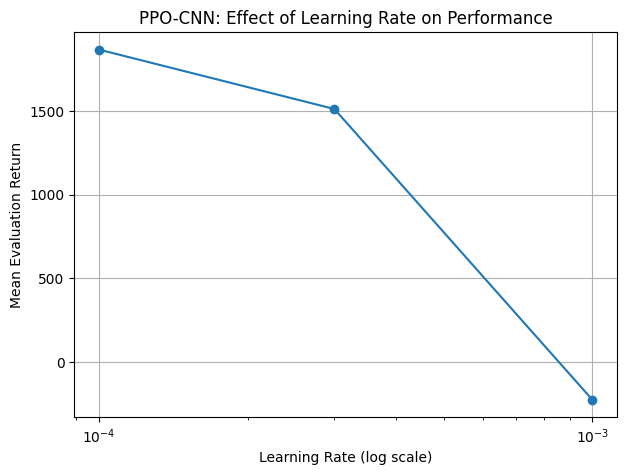

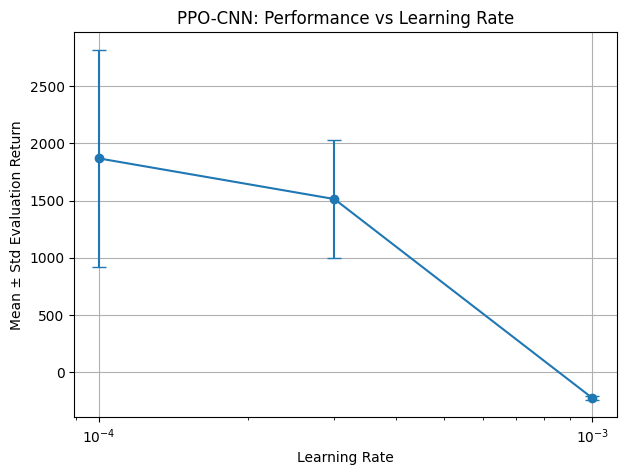

In [ ]:
if lr_varies:
    plt.figure(figsize=(7,5))
    plt.plot(df["learning_rate"], df["mean_eval_return"], marker="o")
    plt.xscale("log")
    plt.xlabel("Learning Rate (log scale)")
    plt.ylabel("Mean Evaluation Return")
    plt.title("PPO-CNN: Effect of Learning Rate on Performance")
    plt.grid(True)
    plt.show()

    # Error bars version (std across eval episodes)
    plt.figure(figsize=(7,5))
    plt.errorbar(
        df["learning_rate"],
        df["mean_eval_return"],
        yerr=df["std_eval_return"],
        marker="o", capsize=5
    )
    plt.xscale("log")
    plt.xlabel("Learning Rate")
    plt.ylabel("Mean ± Std Evaluation Return")
    plt.title("PPO-CNN: Performance vs Learning Rate")
    plt.grid(True)
    plt.show()


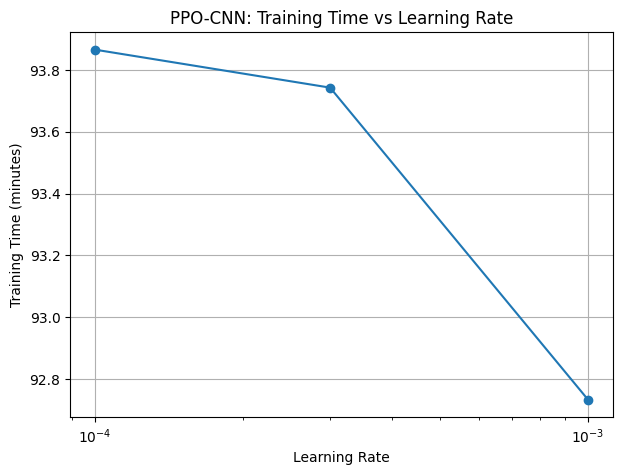

In [ ]:
if lr_varies:
    plt.figure(figsize=(7,5))
    plt.plot(df["learning_rate"], df["train_time_sec"] / 60, marker="o")
    plt.xscale("log")
    plt.xlabel("Learning Rate")
    plt.ylabel("Training Time (minutes)")
    plt.title("PPO-CNN: Training Time vs Learning Rate")
    plt.grid(True)
    plt.show()


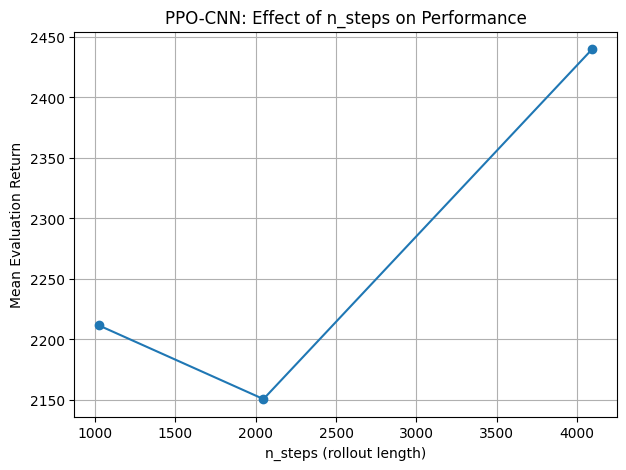

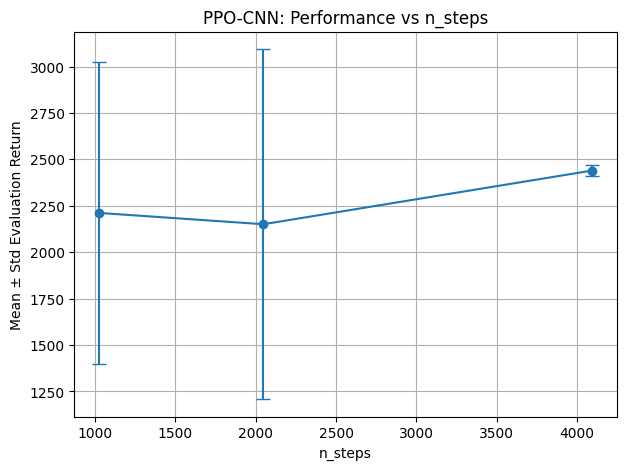

In [ ]:
if nsteps_varies:
    plt.figure(figsize=(7,5))
    plt.plot(df["n_steps"], df["mean_eval_return"], marker="o")
    plt.xlabel("n_steps (rollout length)")
    plt.ylabel("Mean Evaluation Return")
    plt.title("PPO-CNN: Effect of n_steps on Performance")
    plt.grid(True)
    plt.show()

    # Error bars
    plt.figure(figsize=(7,5))
    plt.errorbar(
        df["n_steps"],
        df["mean_eval_return"],
        yerr=df["std_eval_return"],
        marker="o", capsize=5
    )
    plt.xlabel("n_steps")
    plt.ylabel("Mean ± Std Evaluation Return")
    plt.title("PPO-CNN: Performance vs n_steps")
    plt.grid(True)
    plt.show()


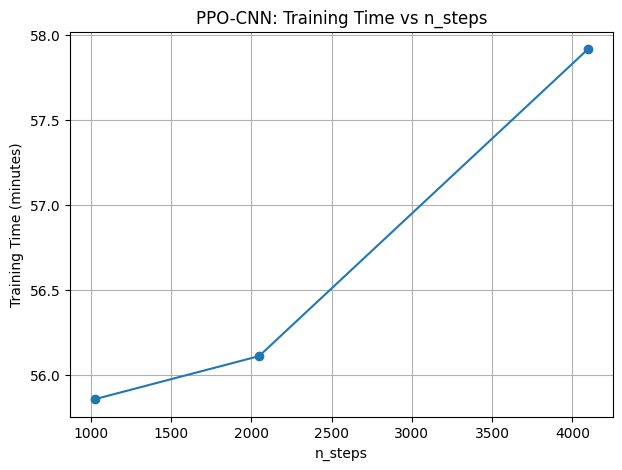

In [ ]:
if nsteps_varies:
    plt.figure(figsize=(7,5))
    plt.plot(df["n_steps"], df["train_time_sec"] / 60, marker="o")
    plt.xlabel("n_steps")
    plt.ylabel("Training Time (minutes)")
    plt.title("PPO-CNN: Training Time vs n_steps")
    plt.grid(True)
    plt.show()


# arch

In [ ]:
import torch
import torch.nn as nn
from gymnasium import spaces
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor


class ConfigurableCarRacingFeatureExtractor(BaseFeaturesExtractor):
    """
    Configurable feature extractor for Dict observation:
      - 'image': (C, H, W) after SB3 preprocessing (e.g. (3, 96, 96))
      - 'state': (N_state,) float

    We keep the *kernel/stride pattern fixed* (8,4) -> (4,2) -> (3,1),
    and only vary the channel sizes + state MLP + final features_dim.
    """

    def __init__(
        self,
        observation_space: spaces.Dict,
        conv_channels=(32, 64, 64),
        state_mlp_dims=(64, 64),
        features_dim: int = 256,
    ):
        super().__init__(observation_space, features_dim=1)

        image_space = observation_space.spaces["image"]
        state_space = observation_space.spaces["state"]

        assert len(image_space.shape) == 3, "Image must be 3D (C, H, W)"
        assert len(state_space.shape) == 1, "State must be 1D vector"

        c, h, w = image_space.shape
        n_input_channels = c

        # ---- CNN branch ----
        # Expect conv_channels of length 3: (c1, c2, c3)
        assert len(conv_channels) == 3, "conv_channels should be a 3-tuple, e.g. (32, 64, 64)"
        c1, c2, c3 = conv_channels

        self.cnn = nn.Sequential(
            nn.Conv2d(n_input_channels, c1, kernel_size=8, stride=4),  # 96 -> 23
            nn.ReLU(),
            nn.Conv2d(c1, c2, kernel_size=4, stride=2),                # 23 -> 10
            nn.ReLU(),
            nn.Conv2d(c2, c3, kernel_size=3, stride=1),                # 10 -> 8
            nn.ReLU(),
            nn.Flatten(),
        )

        # Dummy forward to get CNN output dim
        with torch.no_grad():
            dummy = torch.zeros(1, n_input_channels, h, w)
            cnn_out_dim = self.cnn(dummy).shape[1]

        # ---- State MLP branch ----
        state_dim = state_space.shape[0]
        mlp_layers = []
        in_dim = state_dim
        for hidden_dim in state_mlp_dims:
            mlp_layers.append(nn.Linear(in_dim, hidden_dim))
            mlp_layers.append(nn.ReLU())
            in_dim = hidden_dim
        self.state_net = nn.Sequential(*mlp_layers)
        state_out_dim = state_mlp_dims[-1] if len(state_mlp_dims) > 0 else state_dim

        # ---- Combine + projection ----
        combined_dim = cnn_out_dim + state_out_dim
        self.proj = nn.Sequential(
            nn.Linear(combined_dim, features_dim),
            nn.ReLU(),
        )
        self._features_dim = features_dim

    def forward(self, observations):
        # SB3 has already done channels-first; shape is (B, C, H, W)
        img = observations["image"].float() / 255.0
        state = observations["state"].float()

        img_feat = self.cnn(img)
        state_feat = self.state_net(state)

        concat = torch.cat([img_feat, state_feat], dim=1)
        return self.proj(concat)


In [ ]:
import os
import time
from dataclasses import dataclass, asdict
from typing import List, Tuple

import gymnasium as gym
import numpy as np
import pandas as pd

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy


# ------- Define architecture configs -------

@dataclass
class ArchConfig:
    name: str
    conv_channels: Tuple[int, ...]
    state_mlp_dims: Tuple[int, ...]
    features_dim: int
    policy_net_arch: Tuple[int, ...]
    seed: int = 0
    total_timesteps: int = 200_000
    n_envs: int = 4
    learning_rate: float = 1e-4
    n_steps: int = 2048


arch_configs: List[ArchConfig] = [
    # Smaller model
    ArchConfig(
        name="small_cnn_128feat_2x128mlp",
        conv_channels=(16, 32, 32),
        state_mlp_dims=(64, 64),
        features_dim=128,
        policy_net_arch=(128, 128),
    ),
    # Baseline / medium model
    ArchConfig(
        name="medium_cnn_256feat_2x256mlp",
        conv_channels=(32, 64, 64),
        state_mlp_dims=(64, 64),
        features_dim=256,
        policy_net_arch=(256, 256),
    ),
    # Larger model
    ArchConfig(
        name="large_cnn_512feat_2x512mlp",
        conv_channels=(32, 64, 128),
        state_mlp_dims=(128, 128),
        features_dim=512,
        policy_net_arch=(512, 512),
    ),
]


# ------- Env factories -------

def make_training_env():
    return CarRacing(
        render_mode=None,
        continuous=True,
        lap_complete_percent=0.95,
        domain_randomize=False,
        reward_shaping=True,
        max_episode_steps=3000,
        max_laps=3,
    )


def make_eval_env():
    return CarRacing(
        render_mode=None,
        continuous=True,
        lap_complete_percent=0.95,
        domain_randomize=False,
        reward_shaping=True,
        max_episode_steps=3000,
        max_laps=3,
    )


# ------- Run experiments -------

arch_results = []

base_log_dir = "/content/drive/MyDrive/COMP4010-Project/ppo_cnn_arch_experiments"
os.makedirs(base_log_dir, exist_ok=True)

for cfg in arch_configs:
    print(f"\n=== Running architecture: {cfg.name} ===")
    print(
        f"conv_channels={cfg.conv_channels}, "
        f"state_mlp_dims={cfg.state_mlp_dims}, "
        f"features_dim={cfg.features_dim}, "
        f"policy_net_arch={cfg.policy_net_arch}"
    )

    log_dir = os.path.join(base_log_dir, cfg.name)
    os.makedirs(log_dir, exist_ok=True)
    monitor_path = os.path.join(log_dir, "monitor.csv")

    def env_fn():
        return make_training_env()

    vec_env = make_vec_env(
        env_fn,
        n_envs=cfg.n_envs,
        vec_env_cls=DummyVecEnv,
        seed=cfg.seed,
    )
    vec_env = VecMonitor(vec_env, filename=monitor_path)

    policy_kwargs = dict(
        features_extractor_class=ConfigurableCarRacingFeatureExtractor,
        features_extractor_kwargs=dict(
            conv_channels=cfg.conv_channels,
            state_mlp_dims=cfg.state_mlp_dims,
            features_dim=cfg.features_dim,
        ),
        net_arch=list(cfg.policy_net_arch),
    )

    model = PPO(
        policy="MultiInputPolicy",
        env=vec_env,
        policy_kwargs=policy_kwargs,
        n_steps=cfg.n_steps,
        batch_size=256,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        ent_coef=0.01,
        learning_rate=cfg.learning_rate,
        clip_range=0.2,
        vf_coef=0.5,
        max_grad_norm=0.5,
        tensorboard_log=log_dir,
        verbose=1,
        seed=cfg.seed,
    )

    start_time = time.time()
    model.learn(total_timesteps=cfg.total_timesteps)
    train_time = time.time() - start_time
    print(f"[{cfg.name}] Training finished in {train_time/60:.2f} minutes")

    model_path = os.path.join(log_dir, f"{cfg.name}_final")
    model.save(model_path)

    # Read training curve
    try:
        monitor_df = pd.read_csv(monitor_path, skiprows=1)
        mean_return_last_20 = monitor_df["r"].tail(20).mean()
    except Exception as e:
        print(f"Could not read monitor file for {cfg.name}: {e}")
        mean_return_last_20 = np.nan

    # Evaluate on separate env
    eval_env = make_eval_env()
    mean_eval_return, std_eval_return = evaluate_policy(
        model, eval_env, n_eval_episodes=5, render=False
    )
    eval_env.close()

    row = asdict(cfg)
    row.update(
        dict(
            train_time_sec=train_time,
            mean_return_last_20=mean_return_last_20,
            mean_eval_return=mean_eval_return,
            std_eval_return=std_eval_return,
        )
    )
    arch_results.append(row)

    vec_env.close()

# ------- Summarize and save -------

arch_results_df = pd.DataFrame(arch_results)
display(arch_results_df)

summary_csv_path = os.path.join(base_log_dir, "ppo_cnn_arch_summary.csv")
arch_results_df.to_csv(summary_csv_path, index=False)
print("Saved architecture summary to:", summary_csv_path)



=== Running architecture: small_cnn_128feat_2x128mlp ===
conv_channels=(16, 32, 32), state_mlp_dims=(64, 64), features_dim=128, policy_net_arch=(128, 128)
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /content/drive/MyDrive/COMP4010-Project/ppo_cnn_arch_experiments/small_cnn_128feat_2x128mlp/PPO_2


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/vec_monitor.py:44: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.53e+03 |
|    ep_rew_mean     | -112     |
| time/              |          |
|    fps             | 97       |
|    iterations      | 1        |
|    time_elapsed    | 84       |
|    total_timesteps | 8192     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1.22e+03     |
|    ep_rew_mean          | -86.1        |
| time/                   |              |
|    fps                  | 96           |
|    iterations           | 2            |
|    time_elapsed         | 170          |
|    total_timesteps      | 16384        |
| train/                  |              |
|    approx_kl            | 0.0046666856 |
|    clip_fraction        | 0.0373       |
|    clip_range           | 0.2          |
|    entropy_loss         | -5.69        |
|    explained_variance   | 0.000587     |
|    learning_r

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---
--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---
--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---
--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---
--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---

=== Running architecture: medium_cnn_256feat_2x256mlp ===
conv_channels=(32, 64, 64), state_mlp_dims=(64, 64), features_dim=256, policy_net_arch=(256, 256)
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to /content/drive/MyDrive/COMP4010-Project/ppo_cnn_arch_experiments/medium_cnn_256feat_2x256mlp/PPO_1


...

Logging to /content/drive/MyDrive/COMP4010-Project/ppo_cnn_arch_experiments/large_cnn_512feat_2x512mlp/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.53e+03 |
|    ep_rew_mean     | -111     |
| time/              |          |
|    fps             | 95       |
|    iterations      | 1        |
|    time_elapsed    | 86       |
|    total_timesteps | 8192     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1.19e+03     |
|    ep_rew_mean          | -85.8        |
| time/                   |              |
|    fps                  | 94           |
|    iterations           | 2            |
|    time_elapsed         | 174          |
|    total_timesteps      | 16384        |
| train/                  |              |
|    approx_kl            | 0.0040680664 |
|    clip_fraction        | 0.0325       |
|    clip_range           | 0.2    

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---
--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---
--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---
--- Lap 1 Finished! ---
--- Lap 1 Finished! ---
--- Lap 2 Finished! ---
--- Lap 3 Finished! ---
--- Race Finished! All 3 Laps Completed! ---


,name,conv_channels,state_mlp_dims,features_dim,policy_net_arch,seed,total_timesteps,n_envs,learning_rate,n_steps,train_time_sec,mean_return_last_20,mean_eval_return,std_eval_return
0,small_cnn_128feat_2x128mlp,"(16, 32, 32)","(64, 64)",128,"(128, 128)",0,200000,4,0.0001,2048,2217.076292,419.125938,2423.179993,8.441173
1,medium_cnn_256feat_2x256mlp,"(32, 64, 64)","(64, 64)",256,"(256, 256)",0,200000,4,0.0001,2048,2256.932167,568.360999,1870.035242,694.928413
2,large_cnn_512feat_2x512mlp,"(32, 64, 128)","(128, 128)",512,"(512, 512)",0,200000,4,0.0001,2048,2248.655488,306.439262,2350.272160,582.156246


Saved architecture summary to: /content/drive/MyDrive/COMP4010-Project/ppo_cnn_arch_experiments/ppo_cnn_arch_summary.csv


,name,conv_channels,state_mlp_dims,features_dim,policy_net_arch,seed,total_timesteps,n_envs,learning_rate,n_steps,train_time_sec,mean_return_last_20,mean_eval_return,std_eval_return
0,small_cnn_128feat_2x128mlp,"(16, 32, 32)","(64, 64)",128,"(128, 128)",0,200000,4,0.0001,2048,2217.076292,419.125938,2423.179993,8.441173
1,medium_cnn_256feat_2x256mlp,"(32, 64, 64)","(64, 64)",256,"(256, 256)",0,200000,4,0.0001,2048,2256.932167,568.360999,1870.035242,694.928413
2,large_cnn_512feat_2x512mlp,"(32, 64, 128)","(128, 128)",512,"(512, 512)",0,200000,4,0.0001,2048,2248.655488,306.439262,2350.272160,582.156246


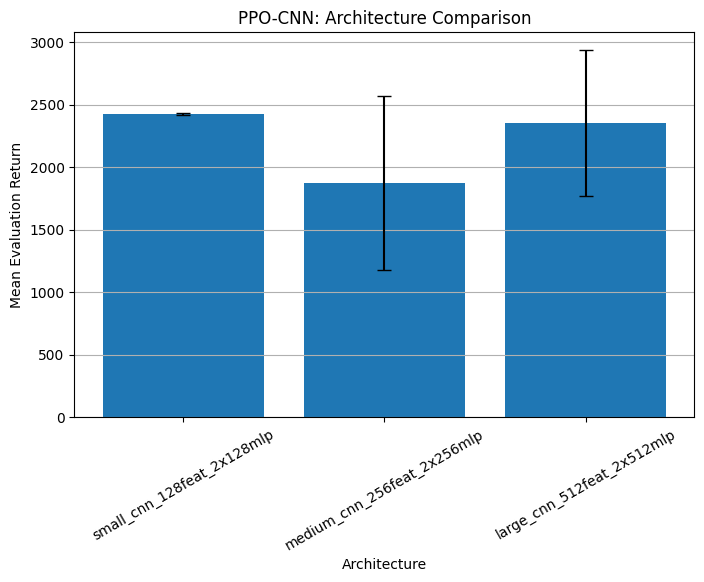

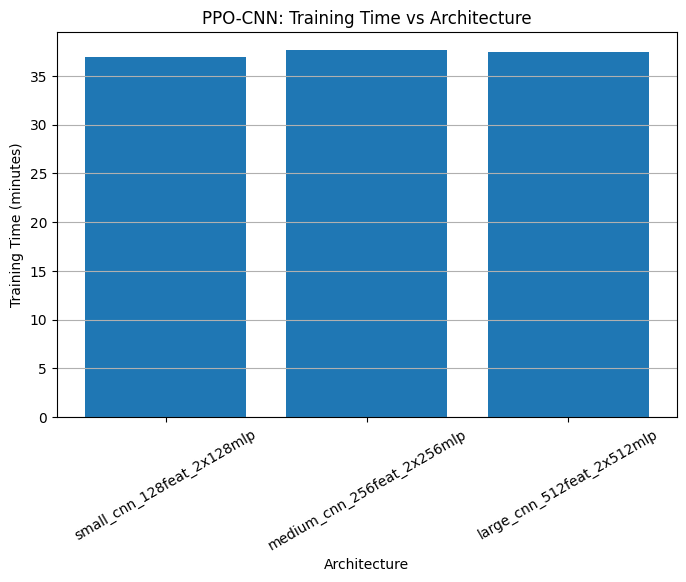

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

arch_summary_path = "/content/drive/MyDrive/COMP4010-Project/ppo_cnn_arch_experiments/ppo_cnn_arch_summary.csv"
df_arch = pd.read_csv(arch_summary_path)
display(df_arch)

plt.figure(figsize=(8,5))
plt.bar(df_arch["name"], df_arch["mean_eval_return"], yerr=df_arch["std_eval_return"], capsize=5)
plt.ylabel("Mean Evaluation Return")
plt.xlabel("Architecture")
plt.title("PPO-CNN: Architecture Comparison")
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.show()

plt.figure(figsize=(8,5))
plt.bar(df_arch["name"], df_arch["train_time_sec"] / 60)
plt.ylabel("Training Time (minutes)")
plt.xlabel("Architecture")
plt.title("PPO-CNN: Training Time vs Architecture")
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.show()
